# CPC ENSO indices

The Climate Prediction Center measures El Niño and La Niña with a seasonal index
of sea surface temperature in the Niño 3.4 region of the central equatorial
Pacific. It publishes two, each as one plain-text table holding every
three-month season since DJF 1950: the traditional Oceanic Niño Index (ONI),
and the Relative Oceanic Niño Index (RONI), which NOAA has used for official
ENSO monitoring since 1 February 2026. Both are computed from ERSST v6.

This walkthrough pulls both tables, reads them with pandas, and shows where
they part: RONI measures Niño 3.4 against the rest of the tropics, so a warming
ocean no longer reads as a stronger El Niño. It needs `usdata[pandas]` and
matplotlib, and downloads two files of under 25 kB.

In [1]:
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; pandas {pd.__version__}")

Executed (UTC): 2026-09-28T20:01:11+00:00
usdata 0.32.0; pandas 3.0.6


## Select

Each table is the whole record, so the manifest gives no window, box, or
variables; `index` names the table, and RONI is the default. The two sources
are named so the result can be looked up by name.

In [2]:
print(manifest.read_text())

name: enso-indices
sources:
  - dataset: noaa:enso-indices
    name: roni
  - dataset: noaa:enso-indices
    name: oni
    params: {index: oni}



## What arrives

The first pull downloads two small text files and writes `dataset.lock.json`
beside the manifest, pinning each checksum. CPC rewrites both in place each
month, by the fifth, so the lockfile records which month's table this was.

In [3]:
result = pull(manifest)
for name in ("roni", "oni"):
    item = result.one(name)
    print(f"{name}: {item.asset.id}  {item.provenance.size:,} bytes  {item.provenance.source_url}")
print("Retrieved (UTC):", result.one("roni").provenance.retrieved_at.isoformat(timespec="seconds"))

roni: RONI.ascii.txt  14,720 bytes  https://www.cpc.ncep.noaa.gov/data/indices/RONI.ascii.txt
oni: oni.ascii.txt  23,000 bytes  https://www.cpc.ncep.noaa.gov/data/indices/oni.ascii.txt
Retrieved (UTC): 2026-09-28T20:01:11+00:00


## Open

There is no bundled reader: the tables are whitespace-delimited text, not CSV,
so `open()` refuses them and pandas reads them directly. Each row is one
overlapping season named by its initials, and `YR` is the year of its middle
month: `DJF 1950` is December 1949 to February 1950. RONI has `ANOM`, the index
itself; ONI also has `TOTAL`, the season's mean temperature. Giving each season
the date of its middle month puts both on one time axis.

In [4]:
SEASONS = ["DJF", "JFM", "FMA", "MAM", "AMJ", "MJJ", "JJA", "JAS", "ASO", "SON", "OND", "NDJ"]


def read_index(item: usdata.FetchedAsset) -> pd.DataFrame:
    """One CPC index table, indexed by the middle month of each season."""
    table = pd.read_csv(item.path, sep=r"\s+")
    month = table["SEAS"].map(SEASONS.index) + 1
    table.index = pd.to_datetime({"year": table["YR"], "month": month, "day": 1})
    return table


roni = read_index(result.one("roni"))
oni = read_index(result.one("oni"))
print(
    f"{len(roni)} seasons, {roni['SEAS'].iloc[0]} {roni['YR'].iloc[0]} to "
    f"{roni['SEAS'].iloc[-1]} {roni['YR'].iloc[-1]}"
)
both = pd.DataFrame({"ONI": oni["ANOM"], "RONI": roni["ANOM"], "season": oni["SEAS"]})
both.tail(4)

919 seasons, DJF 1950 to JJA 2026


,ONI,RONI,season
2026-04-01,0.46,-0.04,MAM
2026-05-01,0.95,0.49,AMJ
2026-06-01,1.39,0.97,MJJ
2026-07-01,1.80,1.36,JJA


## A first look

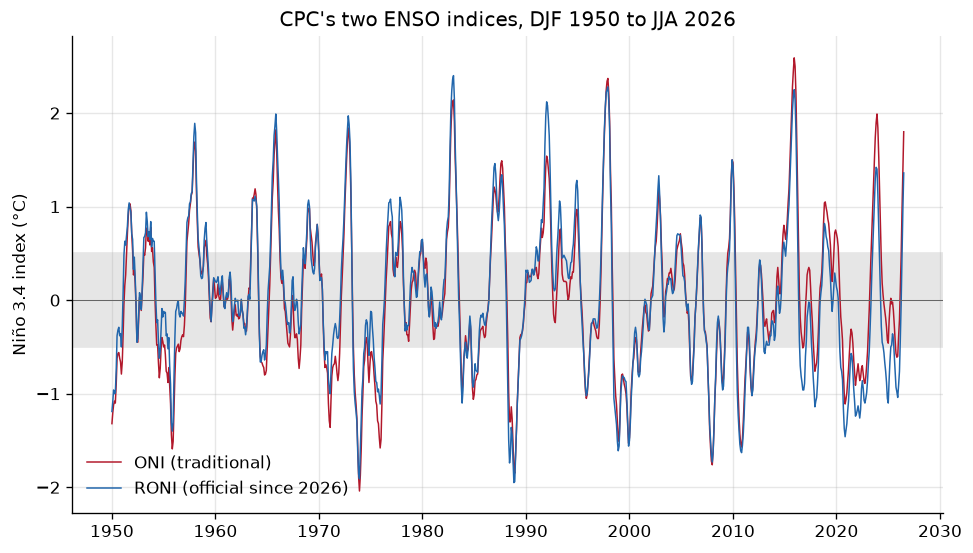

In [5]:
fig, ax = plt.subplots(layout="constrained")
ax.axhspan(-0.5, 0.5, color="0.9", zorder=0)
ax.plot(both.index, both["ONI"], color="#b2182b", linewidth=0.9, label="ONI (traditional)")
ax.plot(
    both.index, both["RONI"], color="#2166ac", linewidth=0.9, label="RONI (official since 2026)"
)
ax.axhline(0, color="0.4", linewidth=0.6)
ax.set_ylabel("Niño 3.4 index (°C)")
ax.set_title("CPC's two ENSO indices, DJF 1950 to JJA 2026")
ax.legend(loc="lower left", frameon=False)
plt.show()

In [6]:
gap = (both["ONI"] - both["RONI"]).groupby(both.index.year // 10 * 10).mean()
print("ONI minus RONI, mean by decade (°C):")
print(gap.round(2).to_string())

ONI minus RONI, mean by decade (°C):
1950   -0.17
1960   -0.09
1970   -0.17
1980   -0.00
1990   -0.11
2000    0.01
2010    0.22
2020    0.44


For most of the record the two lines lie on top of each other. They part
after 2010: ONI measures Niño 3.4 against a base period, and the whole tropical
ocean has warmed against every base period, so ONI reads that warming as El
Niño. RONI subtracts the tropical mean first. In the 2020s ONI reads almost half
a degree higher.

In [7]:
winters = both[both["season"].isin(["OND", "NDJ", "DJF"])].copy()
# A winter is named by the year it starts: OND and NDJ of year y, DJF of y + 1.
winters["winter"] = winters.index.year - (winters["season"] == "DJF")
peaks = winters.groupby("winter")[["ONI", "RONI"]].max()
print("Strongest El Niño winters by peak OND-DJF index (°C):")
print(peaks.sort_values("RONI", ascending=False).head(8).to_string())
latest = both.iloc[-1]
print(
    f"\nLatest season, {latest['season']} {both.index[-1].year}: "
    f"ONI {latest['ONI']:+.2f}, RONI {latest['RONI']:+.2f}"
)

Strongest El Niño winters by peak OND-DJF index (°C):
         ONI  RONI
winter            
1982    2.14  2.40
1997    2.37  2.28
2015    2.59  2.25
1991    1.54  2.12
1965    1.82  1.99
1972    1.84  1.97
1957    1.69  1.89
2009    1.50  1.50

Latest season, JJA 2026: ONI +1.80, RONI +1.36


By RONI the three great events, 1982-83, 1997-98, and 2015-16, stay at the
top, and 1991-92 joins them, where ONI ranked it eighth. 2023-24 falls from
1.99 on ONI to 1.42 on RONI, out of the top eight. The season now under way
parts the same way: JJA 2026 is +1.80 °C on the traditional index and +1.36 °C
on the official one.

## Pin and cite

`verify` checks the cached tables against the lockfile's checksums. CPC
rewrites them monthly and can revise the newest RONI values for two months, so
keep the manifest and lockfile with your results. The citation below is what a
methods section needs, and `usdata cite dataset.yaml` prints the same.

In [8]:
assert verify(manifest) == []
for citation in cite_lockfile(manifest):
    print(citation.as_text())

noaa:enso-indices
  NOAA Climate Prediction Center, Relative Oceanic Niño Index and Oceanic Niño Index, accessed via usdata
  homepage: https://www.cpc.ncep.noaa.gov/products/analysis_monitoring/enso/roni/
  license: US Government Work (public domain)
  terms: https://www.weather.gov/disclaimer
  retrieved: 2026-09-28; 2 checksummed assets (37,720 bytes) pinned by usdata 0.32.0
  sources: roni, oni


## What was awkward

- Two indices share one name in conversation. News of a "super El Niño" can
  rest on the traditional ONI while NOAA's official RONI reads lower, and
  neither file says which is official.
- Seasons are initials and a middle-month year, not dates: putting them on a
  time axis, or grouping them into winters, is a few lines every time.
- The files are whitespace-delimited text with no bundled reader, so `open()`
  refuses them and each notebook calls `pd.read_csv(sep=r"\s+")` itself.
- Each table is rewritten in place under one fixed name, so a pin from last
  month reports a changed file after every update, even when only a new row
  was added.